# Mathematical exercises

Solutions to the following exercises may be either typed into the submitted Jupyter notebook, or handwritten solutions may be scanned and submitted as a separate PDF file.


**Exercise 1** (3 points): Problem 3.11 from the PRML textbook.

# Coding exercises

Reminder: Once your notebook is complete, you should restart the kernel, run all of the cells in order, and make sure that no errors occur. Notebooks that run successfully without errors will be awarded one extra credit point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Linear regression with regularization

Let us return to the regression problem that we studied in the first homework assignment. In that assignment, we showed that cross-validation, i.e. splitting data into training and testing sets, can be an effective strategy to combat overfitting. In this assignment, we'll look at another strategy to combat overfitting: regularization.

As before, let's make some fake data from a sine wave with added noise.

Text(0, 0.5, 'y')

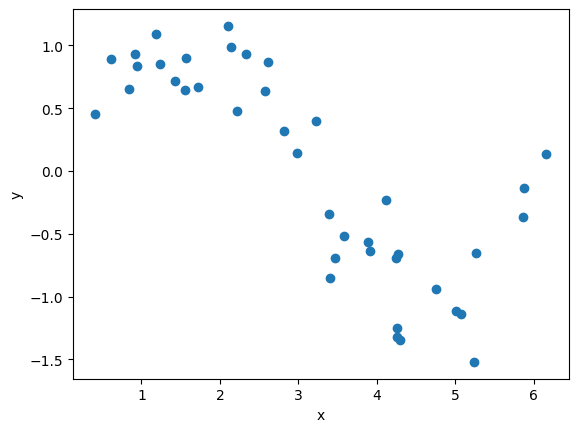

In [2]:
n = 40  # number of data points

# Simulated data:
x_data = 2*np.pi*np.random.rand(n)
noise_amp = 0.3
noise = noise_amp*np.random.randn(n)
y_data = np.sin(x_data) + noise

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')

Next, as in our class demo, let's create polynomial feature vectors from the data and plot the prediction curve:

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/2048070080.py:10: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/2048070080.py:10: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/2048070080.py:10: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data


Text(0, 0.5, 'y')

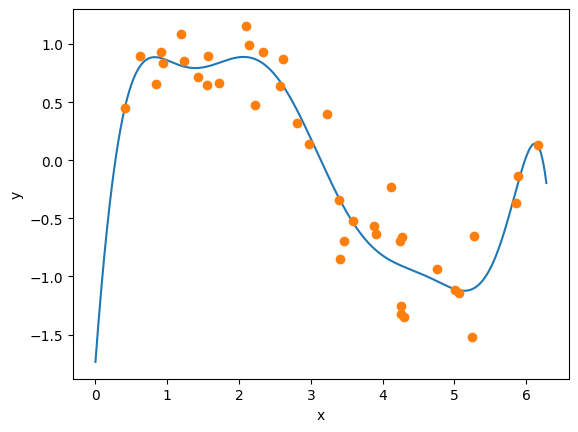

In [3]:
m = 10  # number of feature vectors (i.e. m-1 is the order of the polynomial)
alpha = 0.0  # regularization parameter

# Create the design matrix:
phi = np.zeros((n, m))
for j in range(m):
    phi[:,j] = x_data**j

# The weight vector minimizing the mean squared error:
w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data

# To plot the prediction curve, create an array of x data and corresponding y data:
x_array = np.arange(0, 2*np.pi, 0.01)
y_pred = np.zeros_like(x_array)
for i, x in enumerate(x_array):
    y_pred[i] = np.sum([w[j]*x**j for j in range(m)])
    
plt.plot(x_array, y_pred)
plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')

**Exercise 1** (3 pts): Turn the above block of code into a function, `mse(x_data, y_data, m, alpha)`, that fits a polynomial with `m` parameters to data with regularization parameter `alpha`, as in the above block of code, and returns the MSE. Use this function to plot the MSE for different values of `alpha`, using `plt.semilogx()` to scale the x-axis logarithmically. Explain why the curve that you plot looks the way that it does.

In [4]:
## Solution  ##
def mse(x_data, y_data, m, alpha):

    n = len(x_data)  # Get the number of data points
    
    # Create thae design matrix:
    phi = np.zeros((n, m))
    for j in range(m):
        phi[:,j] = x_data**j

    # The weight vector minimizing the mean squared error:
    w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data

    # Calculate y predictions based on x_data and model
    y_pred = np.zeros_like(y_data)
    for i, x in enumerate(x_data):
        y_pred[i] = np.sum([w[j]*x**j for j in range(m)])
    mean_squared_error = np.mean((y_pred - y_data)**2)
    return mean_squared_error

mse(x_data, y_data, m=10, alpha=0.0)

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4294038999.py:12: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4294038999.py:12: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4294038999.py:12: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data


0.0643733410716798

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4294038999.py:12: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4294038999.py:12: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4294038999.py:12: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data


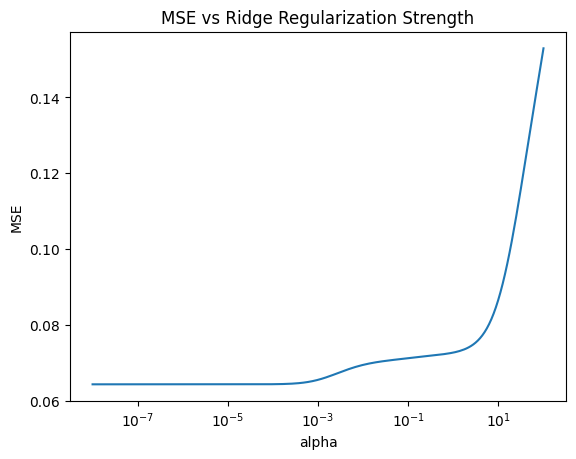

In [5]:
alphas = np.logspace(-8, 2, 200)
mses = [mse(x_data, y_data,m=10, alpha=a)for a in alphas]
plt.figure()
plt.semilogx(alphas, mses)
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('MSE vs Ridge Regularization Strength')
plt.show()

**Answer:** mean squared error increases exponentially as alpha increases because as alpha increases, larger weight values are decreased/removed since their magnitude is accounted as a term in the loss function. so at the largest value of alphas there are the weights are minimal and the model is simplified but does not fit the data as well.

**Exercise 2** (3 points): Create another version of the function from above, calling the new version `mse_cv(x_data, y_data, m, alpha, cv, make_plot)`, that takes two new Boolean arguments. 
- If `cv=True`, perform cross-validation by splitting the data into training and testing sets and performing the fit with just the training data. The function should return both the MSE computed with the training data and the MSE computed with the testing data. 
- If `make_plot=True`, plot the data together with the fit. If cross-validation is used, plot the training and testing data in separate colors, with a legend to distinguish them.

In [6]:
## Solution  ##
def mse_cv(x_data, y_data, m, alpha, cv, make_plot):
    """
    Fit polynomial with optional cross-validation and plotting.
    
    Parameters:
    - cv: If True, split data in half for train/test
    - make_plot: If True, plot the data with the fitted curve
    
    Returns:
    - If cv=False: single MSE value
    - If cv=True: (train_mse, test_mse)
    """
    
    if not cv:
        # No cross-validation: use all data
        n = len(x_data)
        
        # Create design matrix
        phi = np.zeros((n, m))
        for j in range(m):
            phi[:, j] = x_data**j
        
        # Compute weights
        w = np.linalg.inv(alpha*np.eye(m) + phi.T @ phi) @ phi.T @ y_data
        
        # Predictions
        y_pred = phi @ w
        mse_value = np.mean((y_pred - y_data)**2)
        
        if make_plot:
            # Plot data and fit
            x_plot = np.linspace(x_data.min(), x_data.max(), 200)
            y_plot = np.zeros_like(x_plot)
            for i, x in enumerate(x_plot):
                y_plot[i] = np.sum([w[j]*x**j for j in range(m)])
            
            plt.figure(figsize=(8, 5))
            plt.plot(x_data, y_data, 'o', label='Data', alpha=0.6)
            plt.plot(x_plot, y_plot, '-', label=f'Fit (m={m}, α={alpha})', linewidth=2)
            plt.xlabel('x')
            plt.ylabel('y')
            plt.legend()
            plt.title('Polynomial Fit (No CV)')
            plt.show()
        
        return mse_value
    
    else:
        # Cross-validation: split data in half
        n = len(x_data)
        mid = n // 2
        
        x_train, x_test = x_data[:mid], x_data[mid:]
        y_train, y_test = y_data[:mid], y_data[mid:]
        
        phi_train = np.zeros((len(x_train), m))
        for j in range(m):
            phi_train[:, j] = x_train**j
        
        # Fit on training data only
        w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train
        
        # Training MSE
        y_pred_train = phi_train @ w
        mse_train = np.mean((y_pred_train - y_train)**2)
        
        # Testing MSE
        phi_test = np.zeros((len(x_test), m))
        for j in range(m):
            phi_test[:, j] = x_test**j
        y_pred_test = phi_test @ w
        mse_test = np.mean((y_pred_test - y_test)**2)
        
        if make_plot:
            # Plot training data, testing data, and fit
            x_plot = np.linspace(x_data.min(), x_data.max(), 200)
            y_plot = np.zeros_like(x_plot)
            for i, x in enumerate(x_plot):
                y_plot[i] = np.sum([w[j]*x**j for j in range(m)])
            
            plt.figure(figsize=(8, 5))
            plt.plot(x_train, y_train, 'o', label='Training Data', alpha=0.6)
            plt.plot(x_test, y_test, 's', label='Testing Data', alpha=0.6)
            plt.plot(x_plot, y_plot, '-', label=f'Fit (m={m}, α={alpha})', linewidth=2)
            plt.xlabel('x')
            plt.ylabel('y')
            plt.legend()
            plt.title(f'Polynomial Fit with CV (Train MSE={mse_train:.4f}, Test MSE={mse_test:.4f})')
            plt.show()
        
        return mse_train, mse_test

**Exercise 3** (3 points): Use the above function to make a plot of both the training and testing MSE for various values of `alpha`. (This will work best if the values are evenly spaced on a log scale.) Report the value of `alpha` (an approximate value is fine) that minimizes the testing MSE. Finally, use the `make_plot` option in the function above to make two plots of the data along with the fits, where one fit doesn't use regularization, and the other fit uses the optimal value that was just found.

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4240953038.py:62: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4240953038.py:62: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4240953038.py:62: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train


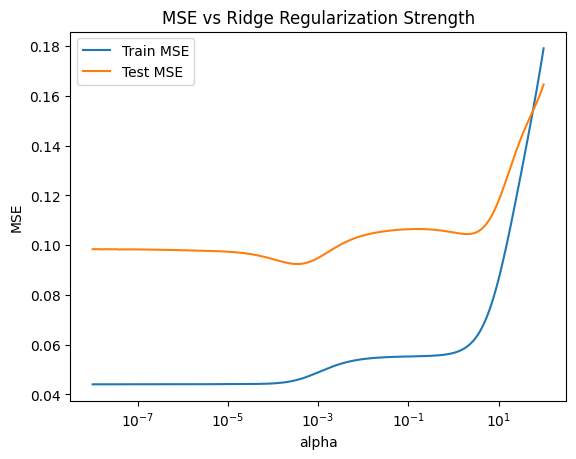

In [7]:
## Solution 
alphas = np.logspace(-8, 2, 200)
mse_train, mse_test = zip(*[mse_cv(x_data, y_data,m=10, alpha=a,cv=True, make_plot=False)for a in alphas])

plt.figure()
plt.semilogx(alphas, mse_train, label='Train MSE')
plt.semilogx(alphas, mse_test, label='Test MSE')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('MSE vs Ridge Regularization Strength')
plt.legend()
plt.show()


In [8]:
min_test_idx = np.argmin(mse_test)
best_alpha = alphas[min_test_idx]
print(f"Best alpha (min test MSE): {best_alpha:.4e}")

Best alpha (min test MSE): 3.3313e-04


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4240953038.py:62: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4240953038.py:62: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_6450/4240953038.py:62: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.inv(alpha*np.eye(m) + phi_train.T @ phi_train) @ phi_train.T @ y_train


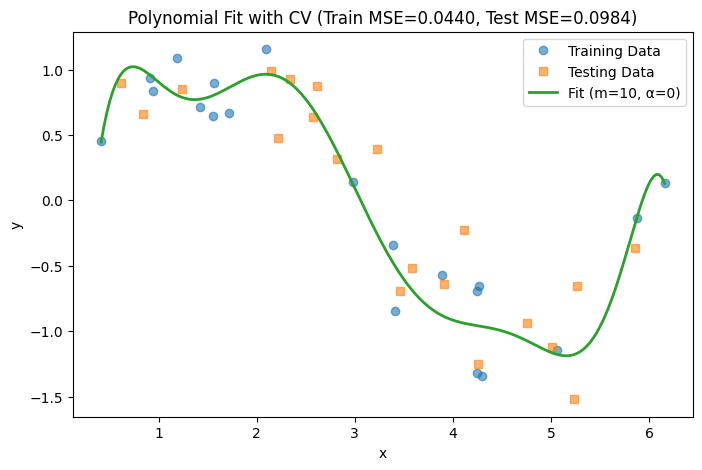

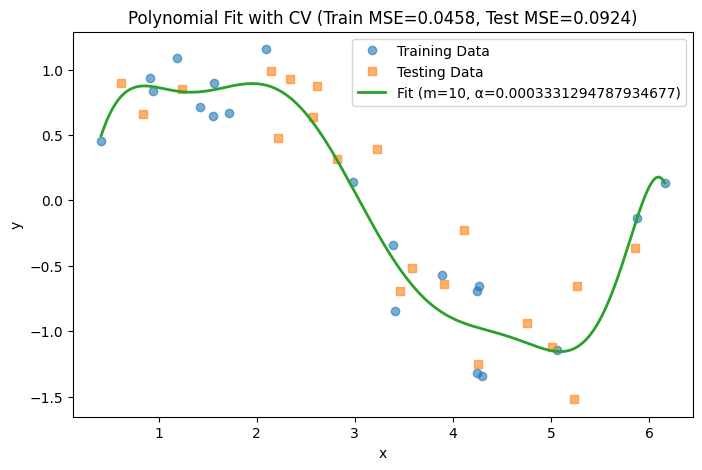

(0.045771340575215216, 0.09239981090788592)

In [9]:
## Solution ##
mse_cv(x_data, y_data, m=10, alpha=0, cv=True, make_plot=True)
mse_cv(x_data, y_data, m=10, alpha=best_alpha, cv=True, make_plot=True)


## Linear regression with a built-in function

Now let's get the same results with less work using a built-in package. 

**Exercise 4** (3 points): Read the documentation for `linear_model.LinearRegression()` from the `sklearn` library, which contains implementations of lots of standard machine algorithms. Following the example in the documentation, and without using regularization, fit a linear model to the first half of our data, then use the `.score()` method to quantify the goodness of fit for both the training set and the testing set. (Note that the score being returned by this function is given by $r^2 = 1 - \mathrm{MSE}/\sigma^2$, where $\sigma^2$ is the variance of the data along the y dimension. This means that scores close to 1 are very good, while negative scores or scores close to zero are bad.) Plot the fit along with the data, with the training and testing data in different colors. The result should match the plot we made above.

In [10]:
from sklearn import linear_model


In [11]:
## Solution ##
# Split data in half
n = len(x_data)
mid = n // 2
x_train, x_test = x_data[:mid], x_data[mid:]
y_train, y_test = y_data[:mid], y_data[mid:]

# Create polynomial features for training data
m = 10
phi_train = np.zeros((len(x_train), m))
for j in range(m):
    phi_train[:, j] = x_train**j

# Create polynomial features for testing data
phi_test = np.zeros((len(x_test), m))
for j in range(m):
    phi_test[:, j] = x_test**j

# Fit linear model (no regularization)
model = linear_model.LinearRegression()
model.fit(phi_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


$r^2 = 1 - \mathrm{MSE}/\sigma^2$, where $\sigma^2$ is the variance of the data along the y dimension. This means that scores close to 1 are very good, while negative scores or scores close to zero are bad.) Plot the fit along with the data, with the training and testing data in different colors. The result should match the plot we made above.

Training R² score: 0.9345
Testing R² score: 0.8508


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


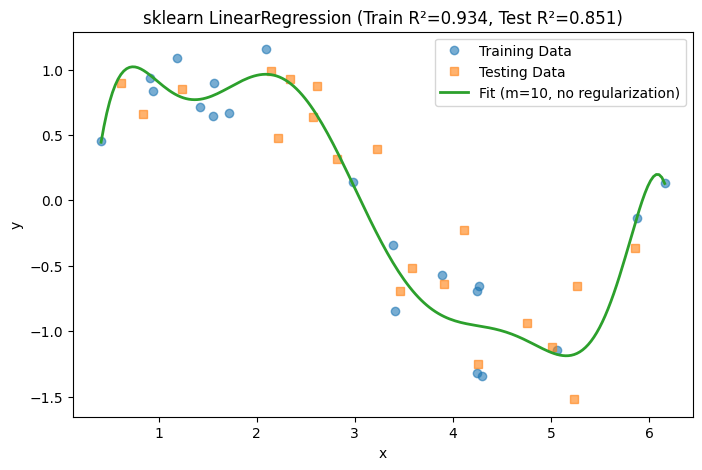

In [12]:
# Score on training and testing data
train_score = model.score(phi_train, y_train)
test_score = model.score(phi_test, y_test)

print(f"Training R² score: {train_score:.4f}")
print(f"Testing R² score: {test_score:.4f}")

# Plot the data and fit
x_plot = np.linspace(x_data.min(), x_data.max(), 200)
phi_plot = np.zeros((len(x_plot), m))
for j in range(m):
    phi_plot[:, j] = x_plot**j
y_plot = model.predict(phi_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_train, y_train, 'o', label='Training Data', alpha=0.6)
plt.plot(x_test, y_test, 's', label='Testing Data', alpha=0.6)
plt.plot(x_plot, y_plot, '-', label=f'Fit (m={m}, no regularization)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'sklearn LinearRegression (Train R²={train_score:.3f}, Test R²={test_score:.3f})')
plt.show()

**Exercise 5** (3 points): Repeat the previous exercise, now using `linear_model.RidgeCV()`, which uses ridge regression (i.e. regularized just as with our `alpha` parameter above) with built-in cross validation (i.e. cross-validation is used to select the best regularization value as we did above, then the result is reported using this optimal value). You should find that the scores for the training and testing datasets are much more similar than before.

Optimal alpha chosen by RidgeCV: 1.0000e+02
Training R² score: 0.9045
Testing R² score: 0.8403


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.18993e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.

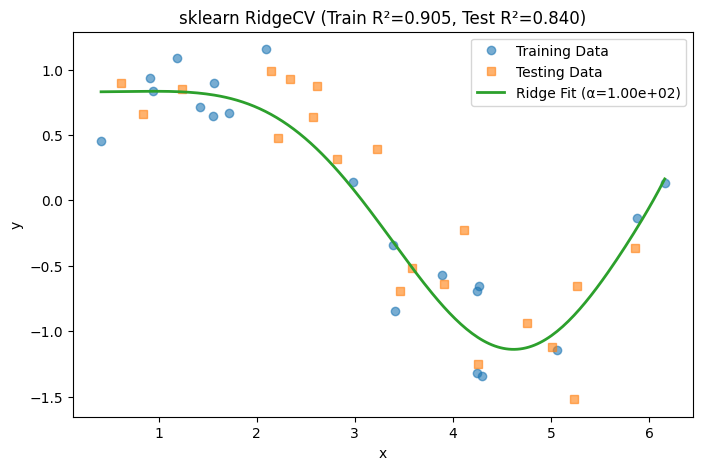

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.05407e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.


Generating R² vs alpha plot...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.7626e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.53344e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Libr

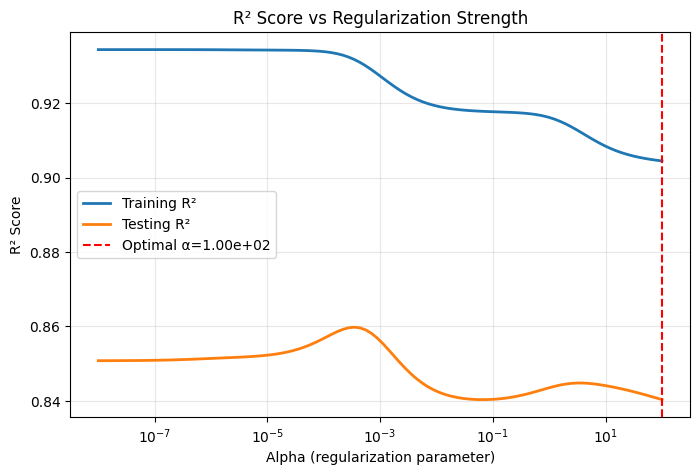

In [14]:
## Solution ##
alphas = np.logspace(-8, 2, 100)

ridge_model = linear_model.RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(phi_train, y_train)

print(f"Optimal alpha chosen by RidgeCV: {ridge_model.alpha_:.4e}")

# Score on training and testing data
train_score_ridge = ridge_model.score(phi_train, y_train)
test_score_ridge = ridge_model.score(phi_test, y_test)

print(f"Training R² score: {train_score_ridge:.4f}")
print(f"Testing R² score: {test_score_ridge:.4f}")

# Plot the data and fit
x_plot = np.linspace(x_data.min(), x_data.max(), 200)
phi_plot = np.zeros((len(x_plot), m))
for j in range(m):
    phi_plot[:, j] = x_plot**j
y_plot_ridge = ridge_model.predict(phi_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_train, y_train, 'o', label='Training Data', alpha=0.6)
plt.plot(x_test, y_test, 's', label='Testing Data', alpha=0.6)
plt.plot(x_plot, y_plot_ridge, '-', label=f'Ridge Fit (α={ridge_model.alpha_:.2e})', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'sklearn RidgeCV (Train R²={train_score_ridge:.3f}, Test R²={test_score_ridge:.3f})')
plt.show()

# Additional plot: R² vs alpha
print("\nGenerating R² vs alpha plot...")
train_scores = []
test_scores = []

for alpha in alphas:
    ridge = linear_model.Ridge(alpha=alpha)
    ridge.fit(phi_train, y_train)
    train_scores.append(ridge.score(phi_train, y_train))
    test_scores.append(ridge.score(phi_test, y_test))

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, train_scores, label='Training R²', linewidth=2)
plt.semilogx(alphas, test_scores, label='Testing R²', linewidth=2)
plt.axvline(ridge_model.alpha_, color='red', linestyle='--', label=f'Optimal α={ridge_model.alpha_:.2e}')
plt.xlabel('Alpha (regularization parameter)')
plt.ylabel('R² Score')
plt.title('R² Score vs Regularization Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Precipitation in Eugene

Below we'll download the data file `EugenePrecip.csv`, which was included along with this homework assignment and contains precipitation data for the city of Eugene over the period Jan 1, 2011 through Dec 31, 2020. The first column in this data denotes a date of the year (from 0 to 365), while the second denotes the precipitation from one day that fell on that date (in inches). Note that, due to missing data, some dates occur fewer than 10 (or possibly not any) times.

In [ ]:
# Load the data (one of several ways to load a CSV file):
from pandas import read_csv
df = read_csv('EugenePrecip.csv')
data = df.values[:,1:]

print(data)

**Exercise 6** (2 points): Since the data is periodic, a linear fit would not be a good choice. Use linear regression with sinusoidal feature vectors (you can decide what particular set of feature vectors is reasonable) to fit the precipitation data. Plot the data along with the fit, making sure that both are clearly legible and that the axes are appropriately labeled. Report the day of the year with the greatest expected precipitation according to the model.

In [ ]:
## Solution ##
# Extract day of year (x) and precipitation (y)
x_precip = data[:, 0]  # Day of year (0-365)
y_precip = data[:, 1]  # Precipitation in inches

# Create sinusoidal basis functions
# Use harmonics: 1, sin(2πd/365), cos(2πd/365), sin(4πd/365), cos(4πd/365), etc.
# This captures annual periodicity
n_harmonics = 5
n_data = len(x_precip)
m_precip = 1 + 2 * n_harmonics  # constant + sin/cos pairs

phi_precip = np.zeros((n_data, m_precip))
phi_precip[:, 0] = 1  # Constant term

for k in range(1, n_harmonics + 1):
    phi_precip[:, 2*k - 1] = np.sin(2 * np.pi * k * x_precip / 365)
    phi_precip[:, 2*k] = np.cos(2 * np.pi * k * x_precip / 365)

# Fit the model using linear regression (no regularization needed for this)
from sklearn import linear_model
precip_model = linear_model.LinearRegression()
precip_model.fit(phi_precip, y_precip)

# Create smooth prediction curve
x_smooth = np.linspace(0, 365, 1000)
phi_smooth = np.zeros((len(x_smooth), m_precip))
phi_smooth[:, 0] = 1
for k in range(1, n_harmonics + 1):
    phi_smooth[:, 2*k - 1] = np.sin(2 * np.pi * k * x_smooth / 365)
    phi_smooth[:, 2*k] = np.cos(2 * np.pi * k * x_smooth / 365)

y_smooth = precip_model.predict(phi_smooth)

# Find day with maximum precipitation
max_idx = np.argmax(y_smooth)
max_day = x_smooth[max_idx]
max_precip = y_smooth[max_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_precip, y_precip, alpha=0.3, s=10, label='Data')
plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'Fit ({n_harmonics} harmonics)')
plt.axvline(max_day, color='green', linestyle='--', alpha=0.7, label=f'Max precip day: {max_day:.0f}')
plt.xlabel('Day of Year')
plt.ylabel('Precipitation (inches)')
plt.title('Eugene Precipitation: Sinusoidal Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 365)
plt.show()

print(f"Day with maximum expected precipitation: Day {max_day:.0f}")
print(f"Maximum expected precipitation: {max_precip:.4f} inches")
print(f"Training R² score: {precip_model.score(phi_precip, y_precip):.4f}")

## Bayesian linear regression

In class, we described a Bayesian approach to linear regression. Rather than choosing the weights to maximize the likelihood and using cross-validation to determine the regularization parameter $\alpha$, the Bayesian approach integrates over the weights using priors $\alpha$ and $\beta$ to get the "model evidence", choosing $\alpha$ and $\beta$ to maximize this evidence. While the determination of $\alpha$ and $\beta$ is rather involved in general, we can make use of an approximation in the limit where the number of data points is much greater than the number of model parameters (i.e. the number of sinusoidal basis functions), i.e. $N\gg M$. In this case, the hyperparameters are given approximately by (cf. Eqs. (3.98) and (3.99) in PRML)
$$
\alpha = \frac{M}{2 E_W(\mathbf{w}_\mathrm{MAP})}
$$
$$
\beta = \frac{N}{2 E_D(\mathbf{w}_\mathrm{MAP})},
$$
where $\mathbf{w}_\mathrm{MAP}$ is the "maximum a posteriori" weight vector, and $E_W$ and $E_D$ are the regularization term and squared error term from the loss function, respectively. Because these quantities themselves depend on $\alpha$ and $\beta$, the above equations must be solved iteratively to determine the optimal values of the hyperparameters.

**Exercise 7** (2 points): Solve the above equations iteratively to obtain the optimal values of $\alpha$ and $\beta$. To do this, assume some initial guesses for $\alpha$ and $\beta$, use these to calculate $E_W$ and $E_D$, then use the above equations to get updated guesses for $\alpha$ and $\beta$. Repeat this until convergence and report the values of $\alpha$ and $\beta$.

In [ ]:
## Solution ##



**Exercise 8** (2 points): With the values of $\alpha$ and $\beta$ obtained in the previous exercise, calculate the uncertainty $\sigma_N(x)$ of the predictive distribution, which we derived in class. Use this to plot a shaded region in your fit to the precipitation value (try using `plt.fill_between()`), where the shading indicates likely values of the model prediction at each value of $x$ (i.e. for each day of the year).

In [ ]:
## Solution ##

